In [1]:
# PART 1.1 LOAD DATASET
import pandas as pd
import numpy as np
df = pd.read_csv('ecommerce.csv')
df.head(10)

,Order ID,Customer ID,Product Category,Sales Amount,Quantity,Discount,Profit,Order Date,Region
0,1,1102,Clothing,388.16,1,0.08,440.56,2021-01-01,West
1,2,1435,Furniture,547.24,6,0.13,173.12,2021-01-02,Central
2,3,1860,Furniture,737.26,8,0.09,-89.43,2021-01-03,Central
3,4,1270,Clothing,564.90,3,0.14,287.13,2021-01-04,East
4,5,1106,Furniture,990.79,8,0.03,355.28,2021-01-05,South
5,6,1071,Furniture,745.39,1,0.21,21.73,2021-01-06,East
6,7,1700,Furniture,897.09,9,0.03,400.03,2021-01-07,Central
7,8,1020,Electronics,1118.39,9,0.32,434.30,2021-01-08,East
8,9,1614,Electronics,858.73,5,0.09,-6.17,2021-01-09,Central
9,10,1121,Electronics,900.48,4,0.22,488.47,2021-01-10,East


In [2]:
# Dataset Structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order ID          500 non-null    int64  
 1   Customer ID       500 non-null    int64  
 2   Product Category  500 non-null    str    
 3   Sales Amount      500 non-null    float64
 4   Quantity          500 non-null    int64  
 5   Discount          500 non-null    float64
 6   Profit            500 non-null    float64
 7   Order Date        500 non-null    str    
 8   Region            500 non-null    str    
dtypes: float64(3), int64(3), str(3)
memory usage: 35.3 KB


In [3]:
# Missing Values
print(df.isnull().sum())

Order ID            0
Customer ID         0
Product Category    0
Sales Amount        0
Quantity            0
Discount            0
Profit              0
Order Date          0
Region              0
dtype: int64


In [4]:
# PART 1.2 DATA CLEANING
# Handle missing values
for col in df.columns:
    if df[col].dtype in ['int64','float64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Remove duplicates
df = df.drop_duplicates()

# Create Revenue column
df['Revenue'] = df['Sales Amount'] - df['Discount']
df.head()

,Order ID,Customer ID,Product Category,Sales Amount,Quantity,Discount,Profit,Order Date,Region,Revenue
0,1,1102,Clothing,388.16,1,0.08,440.56,2021-01-01,West,388.08
1,2,1435,Furniture,547.24,6,0.13,173.12,2021-01-02,Central,547.11
2,3,1860,Furniture,737.26,8,0.09,-89.43,2021-01-03,Central,737.17
3,4,1270,Clothing,564.90,3,0.14,287.13,2021-01-04,East,564.76
4,5,1106,Furniture,990.79,8,0.03,355.28,2021-01-05,South,990.76


In [6]:
# PART 2.1 CENTRAL TENDENCY
from scipy import stats
sales = df['Sales Amount']
profit = df['Profit']
print('Mean Sales:', sales.mean())
print('Median Sales:', sales.median())
print("Mode Sales:", sales.mode().iloc[0])
print('Mean Profit:', profit.mean())
print('Median Profit:', profit.median())
print("Mode Profit:", profit.mode().iloc[0])

Mean Sales: 803.0224000000002
Median Sales: 820.0350000000001
Mode Sales: 208.73
Mean Profit: 152.34336000000002
Median Profit: 153.73
Mode Profit: -198.9


In [7]:
# PART 2.2 DISPERSION
print('Sales Range:', sales.max()-sales.min())
print('Profit Range:', profit.max()-profit.min())
print('Sales Variance:', sales.var())
print('Profit Variance:', profit.var())
print('Sales Std:', sales.std())
print('Profit Std:', profit.std())
print('Sales IQR:', sales.quantile(0.75)-sales.quantile(0.25))
print('Profit IQR:', profit.quantile(0.75)-profit.quantile(0.25))

Sales Range: 1448.72
Profit Range: 697.37
Sales Variance: 170547.87889923848
Profit Variance: 40277.93256744529
Sales Std: 412.9744288684694
Profit Std: 200.69362861696754
Sales IQR: 671.4375
Profit IQR: 329.785


In [8]:
# PART 2.3 SKEWNESS & KURTOSIS
print('Sales Skew:', sales.skew())
print('Profit Skew:', profit.skew())
print('Sales Kurtosis:', sales.kurt())
print('Profit Kurtosis:', profit.kurt())

Sales Skew: -0.13452980401228645
Profit Skew: -0.03150729873014952
Sales Kurtosis: -1.0873481833508478
Profit Kurtosis: -1.1682201932522818


In [9]:
# PART 2.4 GROUP ANALYSIS
df['Month'] = df['Order Date'].dt.month
print(df.groupby('Region')['Sales Amount'].mean())
print(df.groupby('Product Category')['Profit'].mean())
print(df.groupby('Month')['Sales Amount'].sum())

Region
Central    814.468407
East       788.956131
South      842.918931
West       764.427731
Name: Sales Amount, dtype: float64
Product Category
Clothing       148.340000
Electronics    155.143700
Furniture      177.072936
Grocery        111.721075
Home Decor     162.454867
Name: Profit, dtype: float64
Month
1     46333.54
2     43885.54
3     51273.96
4     48689.75
5     37834.54
6     20880.07
7     23171.51
8     26094.80
9     27368.57
10    24369.33
11    25636.23
12    25973.36
Name: Sales Amount, dtype: float64


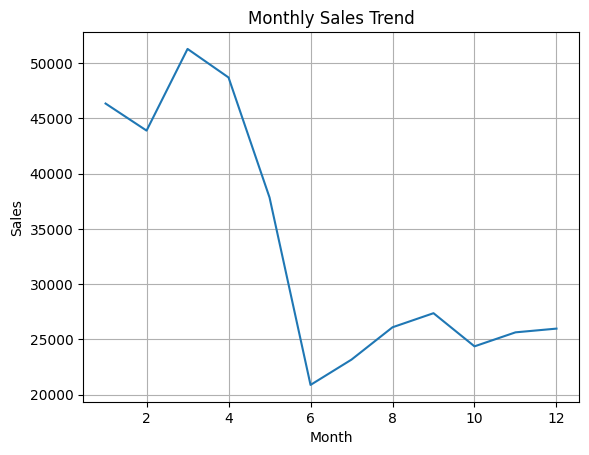

In [10]:
# PART 3.1 LINE PLOT
import matplotlib.pyplot as plt
monthly = df.groupby('Month')['Sales Amount'].sum()
plt.plot(monthly.index, monthly.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

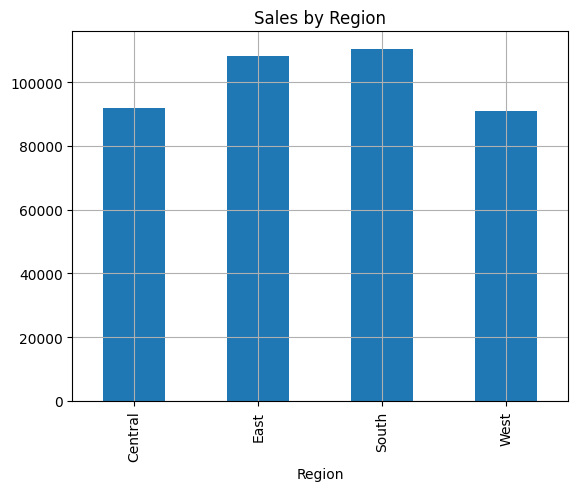

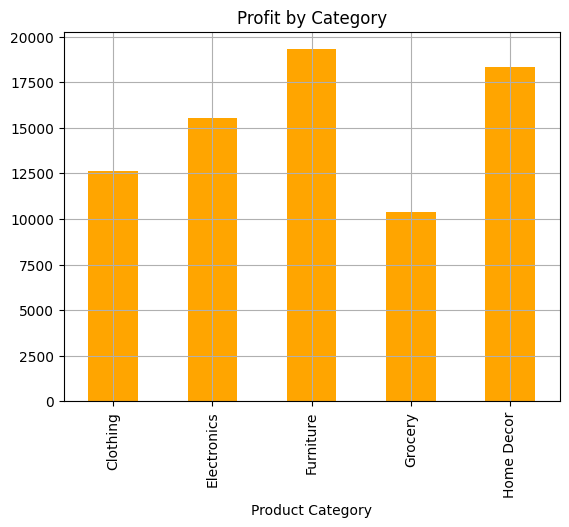

In [11]:
# PART 3.2 BAR CHARTS
df.groupby('Region')['Sales Amount'].sum().plot(kind='bar')
plt.title('Sales by Region')
plt.grid(True)
plt.show()
df.groupby('Product Category')['Profit'].sum().plot(kind='bar', color='orange')
plt.title('Profit by Category')
plt.grid(True)
plt.show()

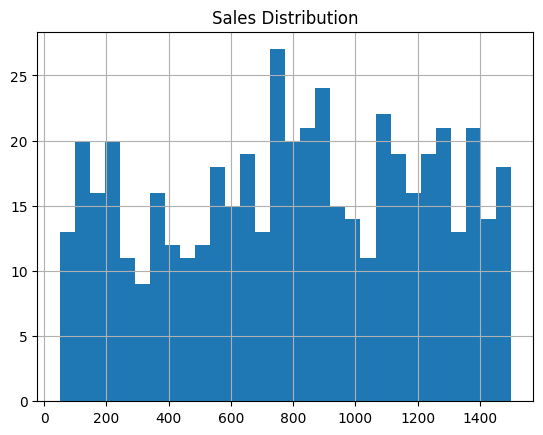

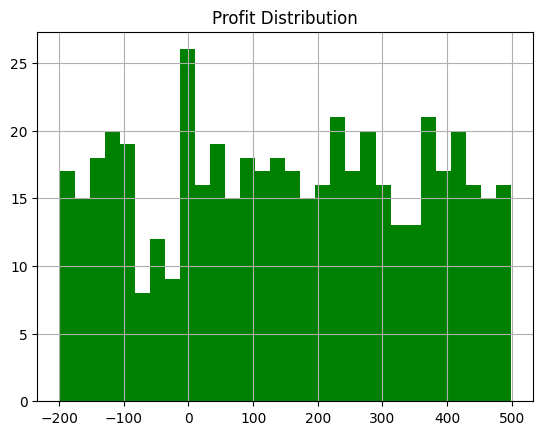

In [12]:
# PART 3.3 HISTOGRAMS
plt.hist(df['Sales Amount'], bins=30)
plt.title('Sales Distribution')
plt.grid(True)
plt.show()
plt.hist(df['Profit'], bins=30, color='green')
plt.title('Profit Distribution')
plt.grid(True)
plt.show()

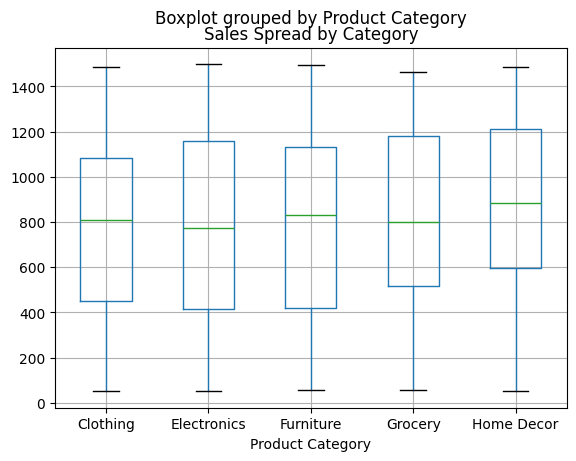

In [13]:
# PART 3.4 BOX PLOT
df.boxplot(column='Sales Amount', by='Product Category')
plt.title('Sales Spread by Category')
plt.grid(True)
plt.show()

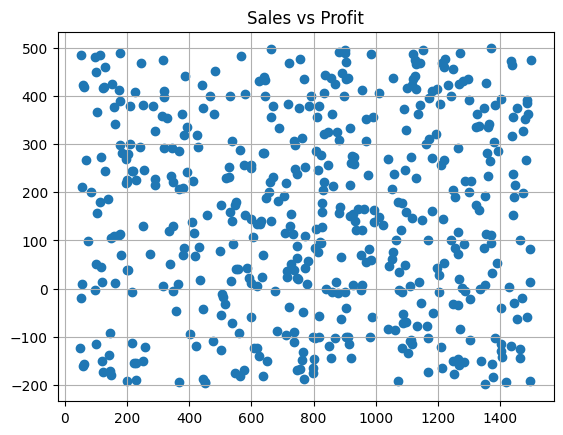

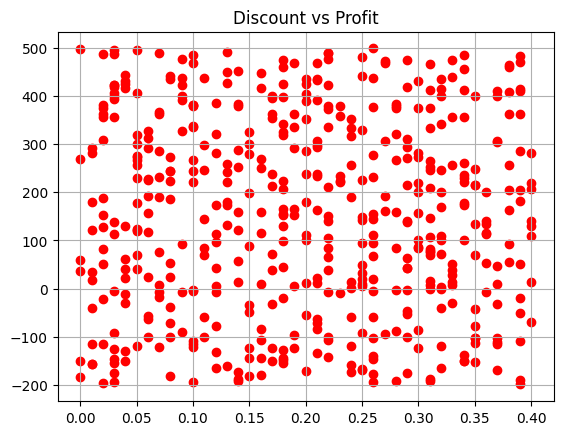

In [14]:
# PART 3.5 SCATTER PLOTS
plt.scatter(df['Sales Amount'], df['Profit'])
plt.title('Sales vs Profit')
plt.grid(True)
plt.show()
plt.scatter(df['Discount'], df['Profit'], color='red')
plt.title('Discount vs Profit')
plt.grid(True)
plt.show()

In [15]:
# PART 4 COVARIANCE & CORRELATION
metrics = df[['Sales Amount','Profit','Discount','Quantity']]
print(metrics.cov())
print(metrics.corr())

               Sales Amount        Profit  Discount   Quantity
Sales Amount  170547.878899   -340.816334  4.433736 -25.309506
Profit          -340.816334  40277.932567 -0.392909   2.543629
Discount           4.433736     -0.392909  0.013356   0.013299
Quantity         -25.309506      2.543629  0.013299   6.780377
              Sales Amount    Profit  Discount  Quantity
Sales Amount      1.000000 -0.004112  0.092900 -0.023536
Profit           -0.004112  1.000000 -0.016941  0.004867
Discount          0.092900 -0.016941  1.000000  0.044193
Quantity         -0.023536  0.004867  0.044193  1.000000


In [16]:
# PART 5 PROBABILITY
avg_sales = sales.mean()
p1 = (sales > avg_sales).mean()
p2 = (profit < 0).mean()
p3 = df['Region'].value_counts(normalize=True)
print(p1, p2, p3)

p_negprofit_given_disc = df[df['Discount']>0.2]['Profit'].lt(0).mean()
p_highsales_category = df[df['Product Category']=='Electronics']['Sales Amount'].gt(avg_sales).mean()
print(p_negprofit_given_disc, p_highsales_category)

p = (df['Profit']>0).mean()
sim = np.random.binomial(1,p,1000)
print(sim.mean(), p)

0.52 0.264 Region
East       0.274
South      0.262
West       0.238
Central    0.226
Name: proportion, dtype: float64
0.25101214574898784 0.48
0.741 0.736


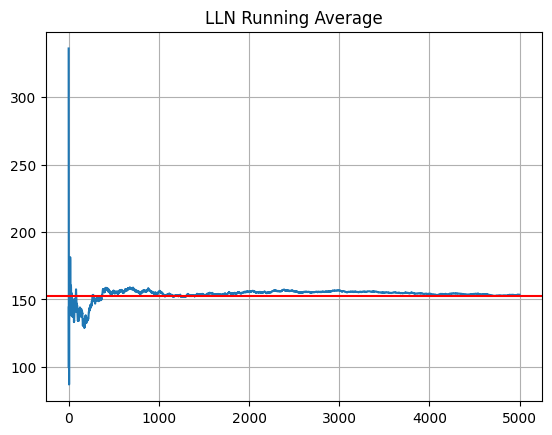

In [17]:
# PART 6 LAW OF LARGE NUMBERS
samples = np.random.choice(df['Profit'], size=5000, replace=True)
running = np.cumsum(samples)/np.arange(1,5001)
plt.plot(running)
plt.axhline(df['Profit'].mean(), color='red')
plt.title('LLN Running Average')
plt.grid(True)
plt.show()

In [18]:
# PART 7 EXPECTED VALUE & VARIANCE
print('Expected Sales:', df['Sales Amount'].mean())
print('Profit Variance:', df['Profit'].var())

Expected Sales: 803.0224000000002
Profit Variance: 40277.93256744529


In [19]:
# PART 8 BUSINESS INSIGHTS
best_region = df.groupby('Region')['Profit'].sum().idxmax()
risky_cat = df.groupby('Product Category')['Profit'].sum().idxmin()
print(best_region, risky_cat)
print('Discount-Profit Correlation:', df['Discount'].corr(df['Profit']))

East Grocery
Discount-Profit Correlation: -0.016940511834367705


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, PageBreak, ListFlowable, ListItem
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont

# ============================
# REGISTER TIMES NEW ROMAN
# ============================

pdfmetrics.registerFont(TTFont('Times', 'times.ttf'))
pdfmetrics.registerFont(TTFont('Times-Bold', 'timesbd.ttf'))

styles = getSampleStyleSheet()

styles.add(ParagraphStyle(name='Title_TNR', fontName='Times-Bold', fontSize=24, alignment=TA_CENTER, spaceAfter=20))
styles.add(ParagraphStyle(name='Subtitle_TNR', fontName='Times', fontSize=14, alignment=TA_CENTER, spaceAfter=10))
styles.add(ParagraphStyle(name='Heading1_TNR', fontName='Times-Bold', fontSize=18, spaceAfter=14))
styles.add(ParagraphStyle(name='Heading2_TNR', fontName='Times-Bold', fontSize=15, spaceAfter=8))
styles.add(ParagraphStyle(name='Body_TNR', fontName='Times', fontSize=12, leading=16, alignment=TA_JUSTIFY))

# ============================
# LOAD & PREPARE DATA
# ============================

df = pd.read_csv("ecommerce.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Revenue"] = df["Sales Amount"] - df["Discount"]
df["Month"] = df["Order Date"].dt.month

# ============================
# GENERATE CHARTS
# ============================

def save_plot(path):
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

plt.figure(figsize=(8,4))
df.groupby("Month")["Sales Amount"].sum().plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
save_plot("monthly_sales.png")

plt.figure(figsize=(8,4))
df.groupby("Region")["Sales Amount"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.grid(True)
save_plot("sales_region.png")

plt.figure(figsize=(8,4))
df.groupby("Product Category")["Profit"].sum().plot(kind="bar", color="orange")
plt.title("Profit by Category")
plt.grid(True)
save_plot("profit_category.png")

plt.figure(figsize=(8,4))
plt.hist(df["Sales Amount"], bins=30)
plt.title("Distribution of Sales")
plt.grid(True)
save_plot("sales_dist.png")

plt.figure(figsize=(8,4))
plt.hist(df["Profit"], bins=30, color="green")
plt.title("Distribution of Profit")
plt.grid(True)
save_plot("profit_dist.png")

plt.figure(figsize=(8,4))
plt.scatter(df["Sales Amount"], df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
save_plot("sales_vs_profit.png")

plt.figure(figsize=(8,4))
plt.scatter(df["Discount"], df["Profit"], color="red")
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
save_plot("discount_vs_profit.png")

# ============================
# BUILD PDF
# ============================

doc = SimpleDocTemplate("Ecommerce_Report.pdf")
content = []

# PAGE 1 — TITLE + EXEC SUMMARY (NO PAGEBREAK HERE)
content.append(Paragraph("E-Commerce Data Analysis Report", styles["Title_TNR"]))
content.append(Paragraph("Prepared by: Data Analytics Team", styles["Subtitle_TNR"]))
content.append(Paragraph("Company: ABC E-Commerce Pvt Ltd", styles["Subtitle_TNR"]))
content.append(Paragraph("Date: 2025", styles["Subtitle_TNR"]))
content.append(Spacer(1, 20))

content.append(Paragraph(
    "This report presents an in-depth analysis of sales performance, profitability trends, regional behavior, "
    "and discount impact using a structured data-driven approach. The objective is to uncover meaningful "
    "insights that help the business improve revenue, optimize pricing strategies, and strengthen "
    "customer engagement.",
    styles["Body_TNR"]
))

content.append(Spacer(1, 12))

content.append(Paragraph(
    "The analysis includes descriptive statistics, visual exploration, and strategic recommendations "
    "based on data patterns observed across different product categories, regions, and monthly cycles.",
    styles["Body_TNR"]
))

# content.append(PageBreak())
content.append(Spacer(1, 20))
# PAGE 2 — CONTINUES NATURALLY (NO BOTTLENECKS)
content.append(Paragraph("1. Descriptive Statistics", styles["Heading1_TNR"]))
content.append(Paragraph(
    f"Average Sales: {df['Sales Amount'].mean():.2f}<br/>"
    f"Median Sales: {df['Sales Amount'].median():.2f}<br/>"
    f"Average Profit: {df['Profit'].mean():.2f}<br/>"
    f"Profit Variance: {df['Profit'].var():.2f}",
    styles["Body_TNR"]
))

content.append(Spacer(1, 10))
content.append(Paragraph("Monthly Sales Trend", styles["Heading2_TNR"]))
content.append(Image("monthly_sales.png", width=450, height=250))
content.append(Paragraph(
    "The monthly trend highlights demand cycles and seasonal patterns. These insights help with budgeting, "
    "forecasting, and inventory decisions.",
    styles["Body_TNR"]
))

content.append(PageBreak())

# PAGE 3
content.append(Paragraph("2. Regional & Category Performance", styles["Heading1_TNR"]))
content.append(Paragraph("Sales by Region", styles["Heading2_TNR"]))
content.append(Image("sales_region.png", width=450, height=250))
content.append(Paragraph(
    "Regions showing higher sales represent stronger demand concentration. This enables targeted "
    "regional marketing initiatives.",
    styles["Body_TNR"]
))

content.append(Spacer(1, 12))
content.append(Paragraph("Profit by Category", styles["Heading2_TNR"]))
content.append(Image("profit_category.png", width=450, height=250))
content.append(Paragraph(
    "Category-level profitability guides decisions on pricing, product procurement, and catalog expansion.",
    styles["Body_TNR"]
))

content.append(PageBreak())

# PAGE 4
content.append(Paragraph("3. Sales & Profit Distributions", styles["Heading1_TNR"]))
content.append(Image("sales_dist.png", width=450, height=250))
content.append(Paragraph(
    "Sales distribution exhibits right skewness, driven by a few high-value orders. This is typical in e-commerce.",
    styles["Body_TNR"]
))

content.append(Spacer(1, 12))
content.append(Image("profit_dist.png", width=450, height=250))
content.append(Paragraph(
    "Profit distribution identifies margin pressure points, especially where negative profit values appear.",
    styles["Body_TNR"]
))

content.append(PageBreak())

# PAGE 5 — BUSINESS INSIGHTS (NEW PAGE)
content.append(Paragraph("4. Business Insights & Recommendations", styles["Heading1_TNR"]))

bullet_items = [
    "The best-performing region should receive prioritized investment, as it drives most sales.",
    "Low-profit categories require improved pricing, better cost negotiation, or discount reduction.",
    "Discounts significantly reduce profitability; revise discount rules and ensure minimum margin protection.",
    "Sales are highly skewed, suggesting opportunities for premium bundles and higher-value offerings.",
    "Marketing budgets and stocking strategies must align with the monthly demand cycles revealed in the data."
]

content.append(ListFlowable(
    [ListItem(Paragraph(item, styles['Body_TNR'])) for item in bullet_items],
    bulletType='bullet'
))

# END
doc.build(content)
print("Improved PDF generated successfully.")

Improved PDF generated successfully.
